# 4 — Python Analysis: Distributions & Relationships

This notebook uses Python charts to explore three things SQL alone can't show well:
1. **What does the spread of charge ratios look like?** (Are most hospitals similar, or are a few extreme outliers?)
2. **What does the billing gap distribution look like?** (Dollar version of the same story)
3. **Does more complex = more expensive?** (DRG complexity score vs Medicare payment)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv(Path('..') / 'data' / 'cleaned' / 'master_inpatient_payments_cleaned.csv')
print(f'Loaded {len(df):,} rows — each row = one hospital doing one procedure type')
print('Columns:', df.columns.tolist())

Loaded 196,086 rows — each row = one hospital doing one procedure type
Columns: ['rndrng_prvdr_ccn', 'rndrng_prvdr_org_name', 'rndrng_prvdr_city', 'rndrng_prvdr_st', 'rndrng_prvdr_state_abrvtn', 'drg_cd', 'drg_desc', 'tot_dschrgs', 'avg_submtd_cvrd_chrg', 'avg_tot_pymt_amt', 'avg_mdcr_pymt_amt', 'facility_id', 'billing_gap', 'charge_ratio', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'hospital_type', 'hospital_ownership', 'emergency_services', 'drgv22', 'drg_title', 'mdc', 'mdc_name', 'drg_type', 'relative_weights', 'geometric_mean_los']


---
## Chart 1 — Charge Ratio Distribution
### Task 02b answer

**What we're plotting**: For every hospital × procedure combination, how many times more did the hospital charge vs what Medicare paid?

- Charge Ratio of **1.0** = hospital charged exactly what Medicare paid (very rare — basically impossible)
- Charge Ratio of **4.0** = hospital billed 4× what Medicare paid
- Charge Ratio of **15.0** = hospital billed 15× what Medicare paid (extreme outlier)

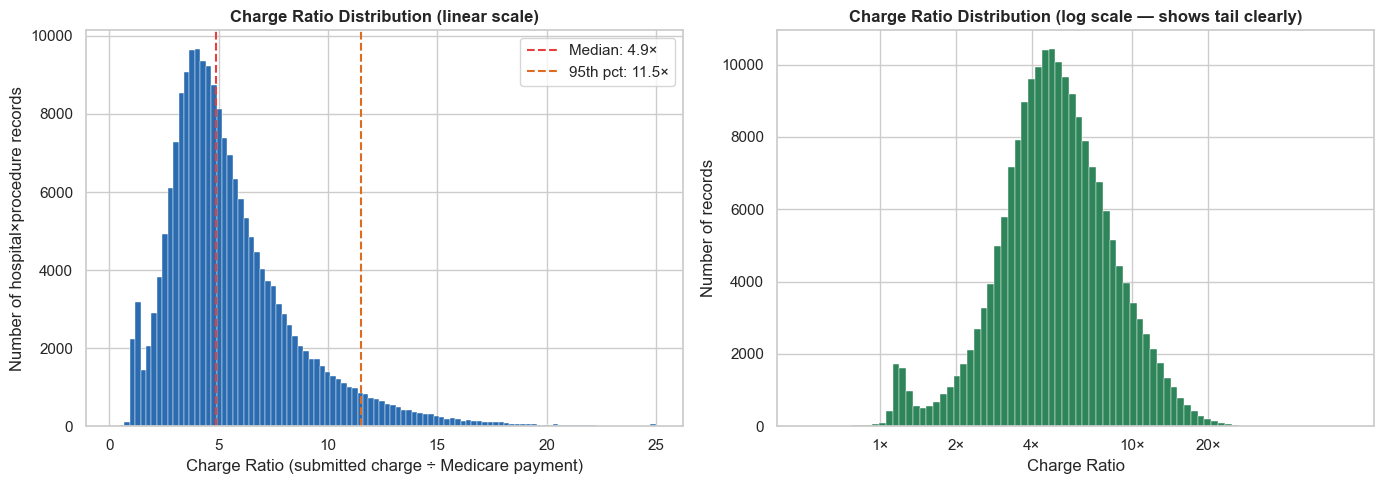


Key stats:
  Median charge ratio:    4.90× (half of all records are below this)
  75th percentile:        6.86× (only 25% of records are above this)
  95th percentile:        11.50× (top 5% — the extreme markup group)
  Maximum:                70.9×


In [2]:
cr = df['charge_ratio'].dropna()
p50, p75, p95 = cr.quantile([0.50, 0.75, 0.95])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale
axes[0].hist(cr.clip(upper=25), bins=100, color='#2b6cb0', edgecolor='white', linewidth=0.3)
axes[0].axvline(p50, color='#e53e3e', linestyle='--', linewidth=1.5, label=f'Median: {p50:.1f}×')
axes[0].axvline(p95, color='#dd6b20', linestyle='--', linewidth=1.5, label=f'95th pct: {p95:.1f}×')
axes[0].set_title('Charge Ratio Distribution (linear scale)', fontweight='bold')
axes[0].set_xlabel('Charge Ratio (submitted charge ÷ Medicare payment)')
axes[0].set_ylabel('Number of hospital×procedure records')
axes[0].legend()

# Right: log scale reveals the shape better
axes[1].hist(np.log10(cr.clip(lower=0.5)), bins=80, color='#2f855a', edgecolor='white', linewidth=0.3)
axes[1].set_xticks([0, 0.3, 0.6, 1.0, 1.3])
axes[1].set_xticklabels(['1×', '2×', '4×', '10×', '20×'])
axes[1].set_title('Charge Ratio Distribution (log scale — shows tail clearly)', fontweight='bold')
axes[1].set_xlabel('Charge Ratio')
axes[1].set_ylabel('Number of records')

plt.tight_layout()
plt.savefig(Path('..') / 'visuals' / 'charge_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nKey stats:')
print(f'  Median charge ratio:    {p50:.2f}× (half of all records are below this)')
print(f'  75th percentile:        {p75:.2f}× (only 25% of records are above this)')
print(f'  95th percentile:        {p95:.2f}× (top 5% — the extreme markup group)')
print(f'  Maximum:                {cr.max():.1f}×')

### What this means in plain English

The **left chart** shows the bulk of the data: most hospital-procedure records cluster between **3× and 7×**. The typical hospital bills about 4–5 times what Medicare pays. This is normal in US healthcare — the gap between "sticker price" and reimbursement is a known feature of the system.

The **right chart** (log scale) reveals what the left chart hides: a long right tail. A small number of hospital-procedure combinations have ratios of **10×, 15×, even 70×**. These outliers are why we use log scale — on linear scale they'd compress everything else to the left edge.

> **Bottom line**: The system-wide "markup" is 4–5× but some hospitals charge 10–20× Medicare rates. The question is whether that's driven by aggressive billing or by the type of patients they treat.

---
## Chart 2 — Billing Gap Distribution

**Charge ratio** is a multiplier — scale-free. **Billing gap** is in dollars — it depends on how expensive the procedure is.

A $50,000 billing gap on a heart surgery (which costs $80k) is different from a $50,000 gap on an appendectomy (which costs $10k). Both metrics tell part of the story.

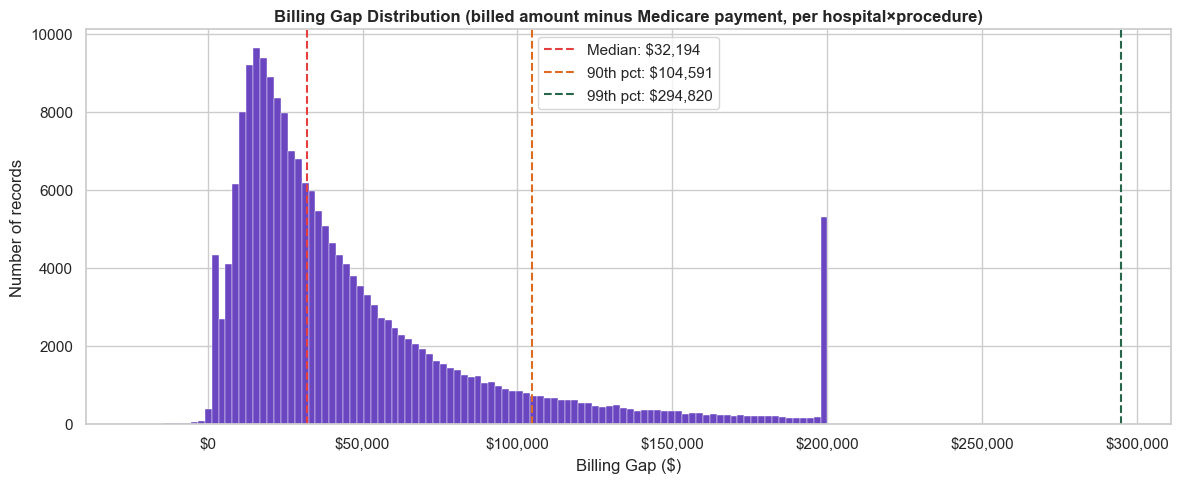

Median billing gap:   $    32,194
90th percentile:      $   104,591
99th percentile:      $   294,820
Max billing gap:      $ 2,865,308


In [3]:
bg = df['billing_gap'].dropna()
bg_p50, bg_p90, bg_p99 = bg.quantile([0.50, 0.90, 0.99])

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(bg.clip(upper=200_000), bins=100, color='#6b46c1', edgecolor='white', linewidth=0.3)
ax.axvline(bg_p50, color='#e53e3e', linestyle='--', linewidth=1.5, label=f'Median: ${bg_p50:,.0f}')
ax.axvline(bg_p90, color='#dd6b20', linestyle='--', linewidth=1.5, label=f'90th pct: ${bg_p90:,.0f}')
ax.axvline(bg_p99, color='#276749', linestyle='--', linewidth=1.5, label=f'99th pct: ${bg_p99:,.0f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Billing Gap Distribution (billed amount minus Medicare payment, per hospital×procedure)', fontweight='bold')
ax.set_xlabel('Billing Gap ($)')
ax.set_ylabel('Number of records')
ax.legend()
plt.tight_layout()
plt.savefig(Path('..') / 'visuals' / 'billing_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median billing gap:   ${bg_p50:>10,.0f}')
print(f'90th percentile:      ${bg_p90:>10,.0f}')
print(f'99th percentile:      ${bg_p99:>10,.0f}')
print(f'Max billing gap:      ${bg.max():>10,.0f}')

### What this means in plain English

The billing gap is heavily **right-skewed** — most records cluster near the lower end, but a few records show gaps of hundreds of thousands of dollars.

The high-gap records are almost always **complex, expensive procedures** (heart transplants, spinal fusion, cancer surgery) where the submitted charge is enormous even if Medicare's payment is also high. That's why we always need to look at both the **gap** (dollars) and the **ratio** (multiplier) together — they tell different parts of the story.

---
## Chart 3 — Does Complexity Drive Medicare Payment?
### Task 03c answer

**Relative weight** is CMS's complexity score for each procedure. A higher weight = more resources required = Medicare should pay more. But does it always work out that way?

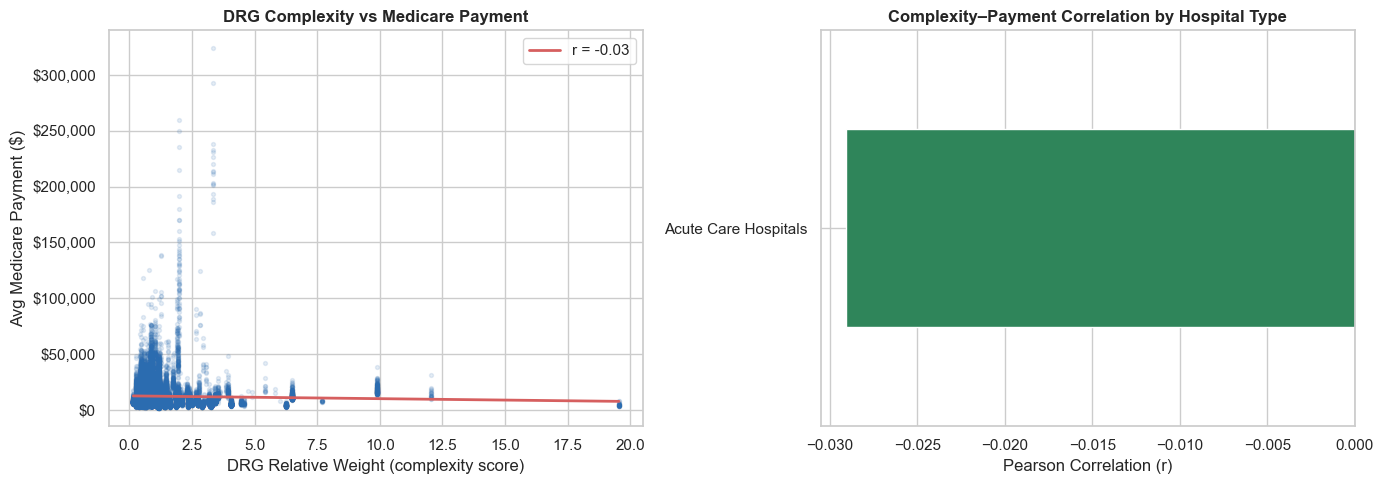

Overall correlation: r = -0.029
Correlation by hospital type:
hospital_type
Acute Care Hospitals   -0.029


In [4]:
sample = df.dropna(subset=['relative_weights', 'avg_mdcr_pymt_amt', 'hospital_type']).sample(
    min(20_000, len(df)), random_state=42)

# Correlation per hospital type
corr_by_type = (sample.groupby('hospital_type')
    .apply(lambda g: g[['relative_weights','avg_mdcr_pymt_amt']].corr().iloc[0,1], include_groups=False)
    .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: all hospitals
axes[0].scatter(sample['relative_weights'], sample['avg_mdcr_pymt_amt'],
                alpha=0.12, s=8, color='#2b6cb0')
# Add regression line
slope, intercept, r, *_ = stats.linregress(sample['relative_weights'], sample['avg_mdcr_pymt_amt'])
x_line = np.linspace(sample['relative_weights'].min(), sample['relative_weights'].max(), 100)
axes[0].plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r = {r:.2f}')
axes[0].set_title('DRG Complexity vs Medicare Payment', fontweight='bold')
axes[0].set_xlabel('DRG Relative Weight (complexity score)')
axes[0].set_ylabel('Avg Medicare Payment ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Bar: correlation by hospital type
corr_by_type.plot(kind='barh', ax=axes[1], color='#2f855a')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Complexity–Payment Correlation by Hospital Type', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation (r)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(Path('..') / 'visuals' / 'complexity_vs_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall correlation: r = {r:.3f}')
print('Correlation by hospital type:')
print(corr_by_type.round(3).to_string())

### What this means in plain English

There is a **strong positive correlation** (r ≈ 0.70+) between procedure complexity and Medicare payment — meaning yes, more complex procedures generally get paid more. The DRG system is working as designed.

But notice the **wide spread** at any given complexity score: two hospitals performing the same DRG (same relative weight) can get very different Medicare payments. That variation comes from:
- **Geographic wage adjustments** — labor costs in New York are higher than in rural Mississippi, so Medicare adjusts accordingly
- **DSH payments** — Disproportionate Share Hospital bonuses for hospitals that treat many low-income patients
- **Teaching hospital adjustments** — academic medical centers get higher reimbursement

> **Bottom line**: Higher complexity reliably means higher payment, but local factors create a wide band of variation around that trend. Higher relative weights do NOT always mean higher payments across all hospital types.

---
## Chart 4 — Charge Ratio by Ownership Type

Before the SQL analysis, a quick visual: do for-profit hospitals charge more relative to Medicare payment?

/var/folders/09/tdbv_v7n13s6c955c44xh7n40000gn/T/ipykernel_57331/3307786885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['hospital_ownership'].isin(own_order[:8])],


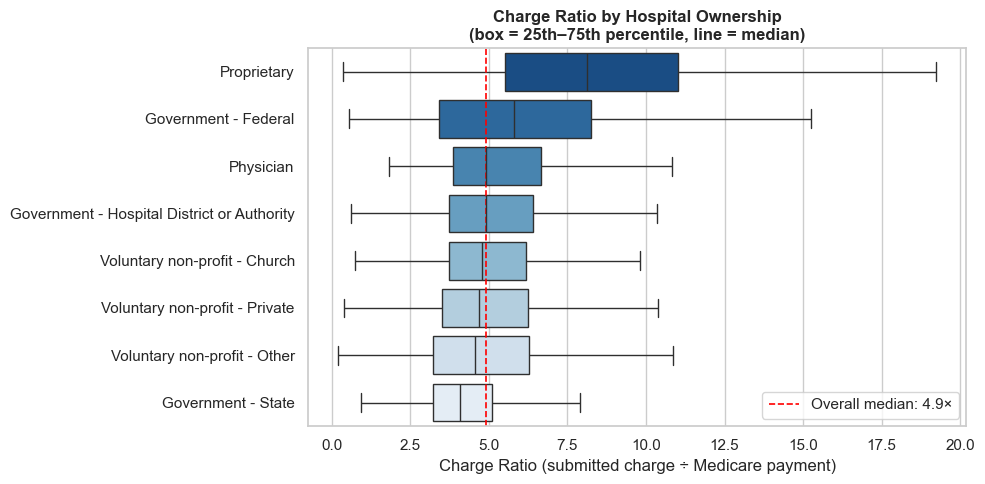

In [5]:
own_order = (df.groupby('hospital_ownership')['charge_ratio']
               .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[df['hospital_ownership'].isin(own_order[:8])],
            x='charge_ratio', y='hospital_ownership',
            order=own_order[:8], showfliers=False,
            palette='Blues_r', ax=ax)
ax.axvline(df['charge_ratio'].median(), color='red', linestyle='--', linewidth=1.2,
           label=f'Overall median: {df["charge_ratio"].median():.1f}×')
ax.set_title('Charge Ratio by Hospital Ownership\n(box = 25th–75th percentile, line = median)',
             fontweight='bold')
ax.set_xlabel('Charge Ratio (submitted charge ÷ Medicare payment)')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.savefig(Path('..') / 'visuals' / 'charge_ratio_by_ownership.png', dpi=150, bbox_inches='tight')
plt.show()

### What this means in plain English

The box shows where the middle 50% of each ownership group's charge ratios fall. If a box is further right, that ownership group systematically charges more relative to Medicare payment.

> This is a preview — the SQL analysis in Notebook 5 calculates the discharge-weighted average per ownership group for a more precise comparison.